# 5. 행렬의 확장 개념

## 행렬의 크기와 정보량은 다르다

- **배울 것**: 열공간·영공간, 랭크, 프로베니우스 노름, 행렬식의 수치적 한계.
- $100\times100$ 행렬이라도 열들이 한 방향의 배수라면 독립적인 정보 방향은 하나뿐입니다. 이 방향의 개수가 랭크입니다.

$$
\mathcal C(A)=\{A\mathbf x\},\qquad
\mathcal N(A)=\{\mathbf x:A\mathbf x=0\},\qquad
\operatorname{rank}(A)+\dim\mathcal N(A)=n
$$

- 열공간은 A가 출력할 수 있는 벡터들의 집합입니다. $m\times n$ 행렬의 열공간은 $\mathbb R^m$ 안에 있습니다.
- 영공간은 변환 후 사라지는 입력들의 집합이며 $\mathbb R^n$ 안에 있습니다.
- $A=\begin{bmatrix}1&2\\3&6\end{bmatrix}$의 열공간은 $(1,3)$ 방향의 직선입니다. $(-2,1)$은 영공간에 있습니다.
- 랭크는 1, 입력 차원은 2이므로 영공간 차원은 $2-1=1$입니다.

## 행렬 사이의 거리

$$
\|A\|_F=\sqrt{\sum_{ij}|a_{ij}|^2}
=\sqrt{\operatorname{tr}(A^TA)},\qquad d(A,B)=\|A-B\|_F
$$

- 실수 행렬에서 프로베니우스 노름은 모든 원소를 한 벡터로 펼쳤을 때의 길이입니다.
- $\|sA\|_F=|s|\|A\|_F$이므로 두 행렬을 함께 줄이면 거리도 같은 비율로 줄어듭니다.
- 이 거리로 재구성 오차를 측정할 수 있습니다. 하지만 단순히 전체 크기를 줄여 얻은 작은 거리는 정보가 더 비슷해졌다는 뜻은 아닙니다.

## 랭크의 규칙과 판정

$$
\operatorname{rank}(AB)\leq\min(\operatorname{rank}A,\operatorname{rank}B),\quad
\operatorname{rank}(A+B)\leq\operatorname{rank}A+\operatorname{rank}B
$$

- 벡터를 열로 추가했을 때 랭크가 증가하지 않으면 기존 열공간으로 표현할 수 있습니다.
- $A,A^T,A^TA,AA^T$는 정확한 수학에서는 같은 랭크입니다. 실제 계산에서는 제곱으로 조건수가 악화되어 다르게 판정될 수 있습니다.
- 정사각행렬의 행렬식이 0이면 특이행렬입니다. 다만 큰 행렬의 행렬식은 스케일과 반올림에 민감하므로 `det(A)==0`만으로 수치 랭크를 판정하지 않습니다.
- **주의**: 수치 랭크는 특잇값을 허용오차와 비교해 정합니다. 부동소수점에서 아주 작은 값은 정확한 0과 다릅니다.

## 읽기 안내

- 이 글은 제공된 Python 예제를 바탕으로 새로 작성한 해설입니다. 연습문제의 질문은 코드에서 확인되는 학습 목표를 재구성했으며 책의 문제 원문을 옮긴 것이 아닙니다.
- 코드·실행 결과는 아래 순서로 연결됩니다. 앞 셀의 변수를 쓰므로 노트북은 처음부터 실행하세요.
- 난수 시드는 장마다 고정했습니다. 실행 시간과 마지막 소수 자릿수는 환경에 따라 달라질 수 있습니다.
- `1e-14` 같은 작은 잔차는 부동소수점 오차일 수 있습니다. 수학적 0과 컴퓨터의 정확한 0을 구분하세요.

## 실행 환경


In [1]:
from pathlib import Path
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT / 'blog_linear_algebra'
DATA = ROOT / 'data'
ASSET = ROOT / 'assets' / 'ch05'
ASSET.mkdir(parents=True, exist_ok=True)
np.random.seed(20260930)
np.set_printoptions(precision=6, suppress=True, threshold=120)
plt.rcParams.update({'figure.dpi': 100, 'savefig.dpi': 140, 'font.size': 12})
print('재현용 난수 시드:', 20260930)

재현용 난수 시드: 20260930


### 코드 05-01

- 원본: `original_py/LA4DS_ch05.py` 1–14행.
- **보완**: Markdown 호환을 위해 그림 출력을 PNG로 지정했습니다.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# for null spaces
import scipy.linalg

# a pretty-looking matrix from scipy
from scipy.linalg import toeplitz


# NOTE: these lines define global figure properties used for publication.
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('png') # print figures in svg format
plt.rcParams.update({'font.size':14}) # set global font size

### 열공간

### 코드 05-02

- 원본: `original_py/LA4DS_ch05.py` 18–38행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

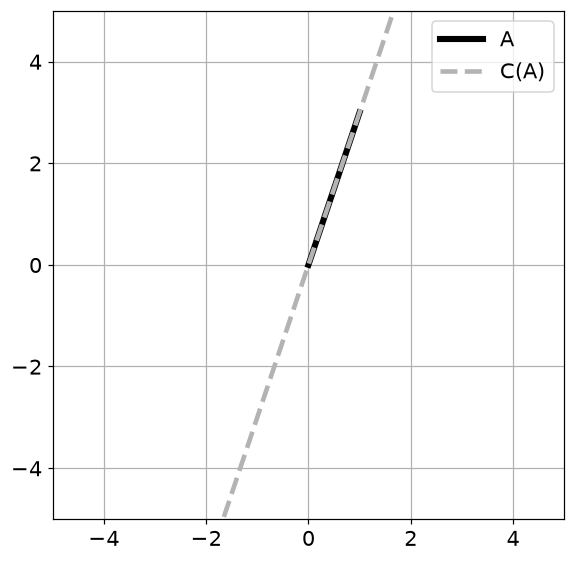

In [3]:
# some matrix (just one lonely little column)
A  = np.array([ [1],[3] ])


# The column space contains an infinite number of points, but for computational convenience,
# we can draw the line using only two points
xlim = [-5,5]
colspace_p1 = xlim[0]*A
colspace_p2 = xlim[1]*A

plt.figure(figsize=(6,6))

plt.plot([0,A[0,0]],[0,A[1,0]],'k',linewidth=4,label='A')
plt.plot([colspace_p1[0,0],colspace_p2[0,0]],[colspace_p1[1,0],colspace_p2[1,0]],
         '--',linewidth=3,color=[.7,.7,.7],label='C(A)')
plt.xlim(xlim)
plt.ylim(xlim)
plt.legend()
plt.grid()
plt.savefig(ASSET / 'Figure_05_01.png',dpi=140)
plt.show()

### 코드 05-03

- 원본: `original_py/LA4DS_ch05.py` 40–69행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

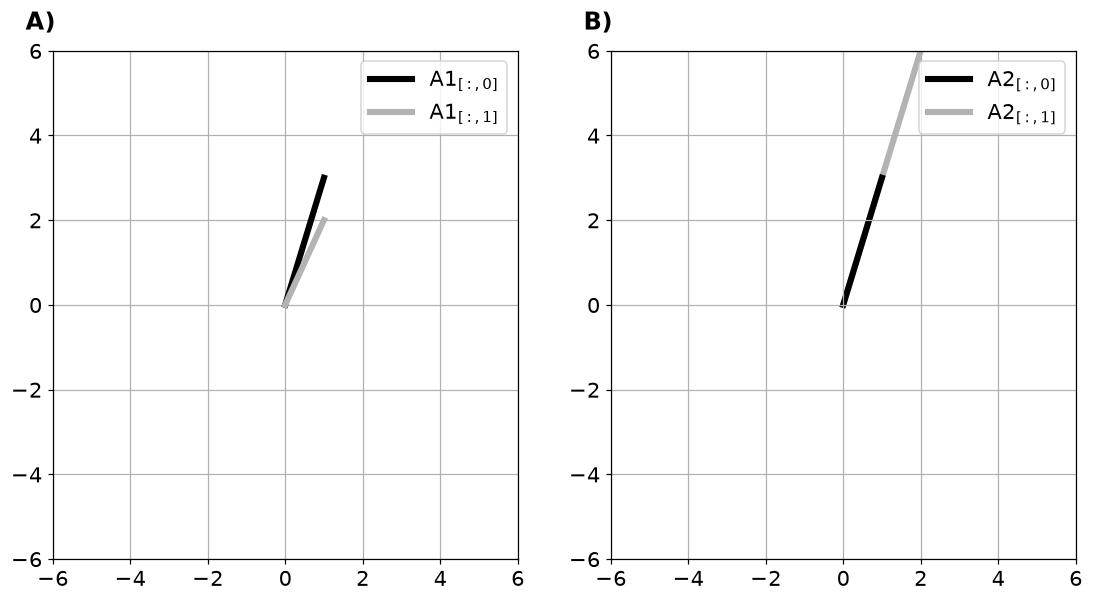

In [4]:
# some matrix
A1  = np.array([ [1,1],[3,2] ])
A2  = np.array([ [1,2],[3,6] ])



# some other plotting specifications
xlim = [-6,6]
color = [ [0,0,0],[.7,.7,.7] ]


# make the plot
_,axs = plt.subplots(1,2,figsize=(12,6))

# loop over columns
for i in range(2):
  axs[0].plot([0,A1[0,i]],[0,A1[1,i]],color=color[i],linewidth=4)
  axs[1].plot([0,A2[0,i]],[0,A2[1,i]],color=color[i],linewidth=4,zorder=-i)
  
  # set some axis properties
  axs[i].set_xlim(xlim)
  axs[i].set_ylim(xlim)
  axs[i].grid()
  axs[i].text(xlim[0]-.7,xlim[1]+.5,f'{"AB"[i]})',fontweight='bold',fontsize=16)

# set the legends and subplot letters
for i in [0,1]: axs[i].legend([f'A{i+1}$_{{[:,0]}}$',f'A{i+1}$_{{[:,1]}}$'])

plt.savefig(ASSET / 'Figure_05_02.png',dpi=140)
plt.show()

### 3차원 열공간

### 코드 05-04

- 원본: `original_py/LA4DS_ch05.py` 73–94행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

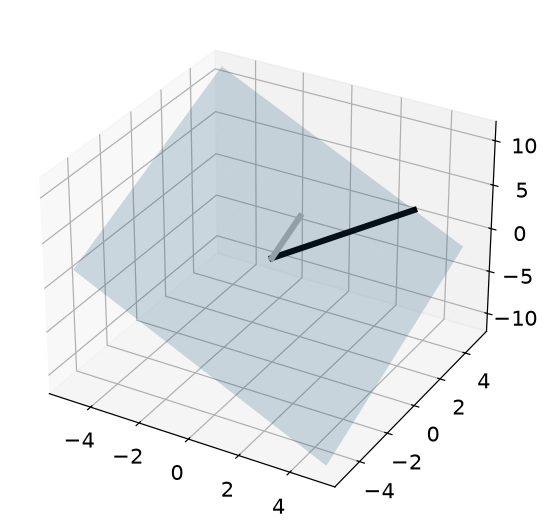

In [5]:
# a matrix with two columns in R3
A = np.array( [ [3,0],
                [5,2],
                [1,2] ] )


# create a 3D graph
ax = plt.figure(figsize=(6,6)).add_subplot(111, projection='3d')

# draw plane corresponding to the column space
xx, yy = np.meshgrid(np.linspace(-5,5,10),np.linspace(-5,5,10))
cp = np.cross(A[:,0],A[:,1])
z1 = (-cp[0]*xx - cp[1]*yy)/cp[2]
ax.plot_surface(xx,yy,z1,alpha=.2)


## plot the two vectors from matrix S
ax.plot([0, A[0,0]],[0, A[1,0]],[0, A[2,0]],color=color[0],linewidth=4)
ax.plot([0, A[0,1]],[0, A[1,1]],[0, A[2,1]],color=color[1],linewidth=4)

plt.savefig(ASSET / 'Figure_05_03.png',dpi=140)
plt.show()

### 영공간

### 코드 05-05

- 원본: `original_py/LA4DS_ch05.py` 98–106행.

In [6]:
# The two matrices
A = np.array([ [1,-1],[-2,2] ])
B = np.array([ [1,-1],[-2,3] ])

# null spaces
print( scipy.linalg.null_space(A) )
print(' ')

print( scipy.linalg.null_space(B) )

[[0.707107]
 [0.707107]]
 
[]


### 코드 05-06

- 원본: `original_py/LA4DS_ch05.py` 108–142행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

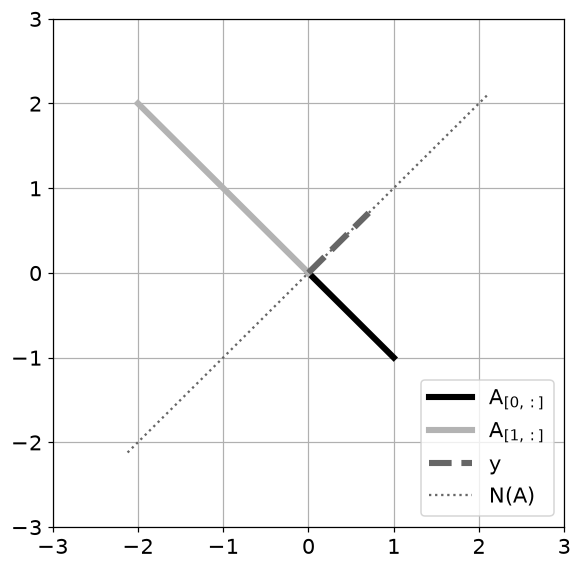

In [7]:
# Using matrix A above

nullvect = scipy.linalg.null_space(A)



# some other plotting specifications
xlim = [-3,3]
color = [ [0,0,0],[.7,.7,.7] ]


# make the plot
plt.figure(figsize=(6,6))

# plot the rows
for i in range(2):
  plt.plot([0,A[i,0]],[0,A[i,1]],color=color[i],linewidth=4,label='A$_{{[%g,:]}}$'%i)

# plot the nullspace vector
plt.plot([0,nullvect[0,0]],[0,nullvect[1,0]],'--',color=[.4,.4,.4],
         linewidth=4,label='y')

# plot the rest of the nullspace
plt.plot([xlim[0]*nullvect[0,0],xlim[1]*nullvect[0,0]],
         [xlim[0]*nullvect[1,0],xlim[1]*nullvect[1,0]],
         ':',color=[.4,.4,.4],label='N(A)')

# set some axis properties
plt.xlim(xlim)
plt.ylim(xlim)
plt.grid()
plt.legend()

plt.savefig(ASSET / 'Figure_05_04.png',dpi=140)
plt.show()

## 연습문제 1 · 스칼라와 노름

- **목표**: 행렬의 스케일 변화가 프로베니우스 노름에 미치는 영향을 확인합니다.
- **풀이 순서**: 스칼라를 0부터 50까지 바꾸고 각 값에서 난수 행렬 10개를 생성해 평균 노름을 그립니다.
- **결과 해석**: 평균적으로 비례합니다. 각 스칼라에서 다른 난수 행렬을 사용하므로 점들이 정확한 직선에 놓일 필요는 없습니다. 0배 행렬은 노름 0입니다.

### 코드 05-07

- 원본: `original_py/LA4DS_ch05.py` 148–175행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


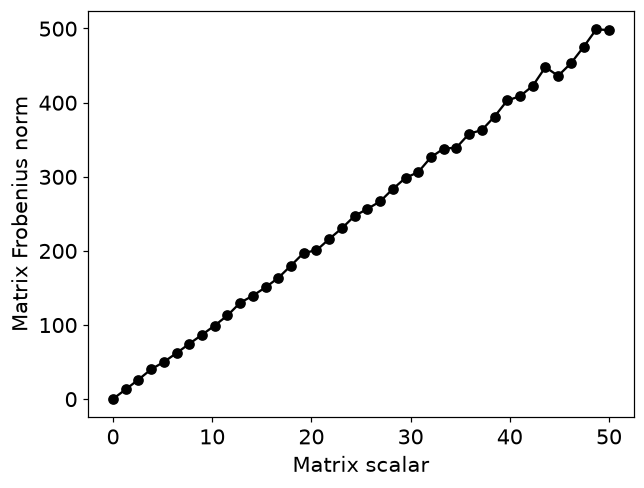

In [8]:
# experiment simulations
scalingVals = np.linspace(0,50,40) # range of scaling parameters (0 to 50 in 40 steps)
nExperiments = 10


# initialize output
matrixNorms = np.zeros((len(scalingVals),nExperiments))

# run experiment!
for si in range(len(scalingVals)):
  for expi in range(nExperiments):

    # generate a random scaled matrix
    R = np.random.randn(10,10) * scalingVals[si]

    # store its norm
    matrixNorms[si,expi] = np.linalg.norm(R,'fro')


# plot the results!
plt.plot(scalingVals,np.mean(matrixNorms,axis=1),'ko-')
plt.xlabel('Matrix scalar')
plt.ylabel('Matrix Frobenius norm')
plt.savefig(ASSET / 'Figure_05_07.png',dpi=140)
plt.show()

# check that norm=0 for zeros matrix
print(matrixNorms[0,:])

## 연습문제 2 · 거리와 반복 축소

- **목표**: 두 행렬 간 거리가 1 이하가 될 때까지 함께 축소합니다.
- **풀이 순서**: $d=\|A-B\|_F$를 직접 구현하고 매번 s에 0.9를 곱합니다. 종료 후 $s\|A-B\|_F\le1$인지 봅니다.
- **결과 해석**: 최종 거리 조건을 만족해야 합니다. 원본은 출력에서 마지막 반복을 되돌렸으므로 이를 수정했습니다. 반복 히스토그램은 초기 거리의 난수 차이를 보여 줍니다.

### 코드 05-08

- 원본: `original_py/LA4DS_ch05.py` 179–187행.

In [9]:
# Function to compute Euclidean distance

def EuclideanDistance(M1,M2):
  
  # matrix difference
  D = M1-M2

  # matrix distance
  return np.sqrt(np.sum(D**2))

### 코드 05-09

- 원본: `original_py/LA4DS_ch05.py` 189–207행.
- **보완**: 반복문 종료 시 이미 거리 조건을 만족하므로 마지막 반복을 취소하던 출력 오류를 수정했습니다.
- **보완**: 최종 스케일을 그대로 출력합니다.
- **보완**: 종료 조건을 만족한 최종 거리를 출력합니다.

In [10]:
# optimization code

# create two matrices
N = 7
A = np.random.randn(N,N)
B = np.random.randn(N,N)

# optimization
numIters = 0
s = 1
while EuclideanDistance(s*A,s*B)>1:
  s *= .9
  numIters += 1

# report the results. Note that my loop code scales once more after criteria is reached,
# so I subtract one from numIters and undo the final s scaling.
print(f'Number of iterations: {numIters}')
print(f'Final value of scalar: {s:.3f}')
print(f'Final Euclidean distance: {EuclideanDistance(s*A,s*B):.3f}')

Number of iterations: 22
Final value of scalar: 0.098
Final Euclidean distance: 0.917


### 코드 05-10

- 원본: `original_py/LA4DS_ch05.py` 209–227행.
- **보완**: 반복 횟수 집계의 1 차이를 수정했습니다.

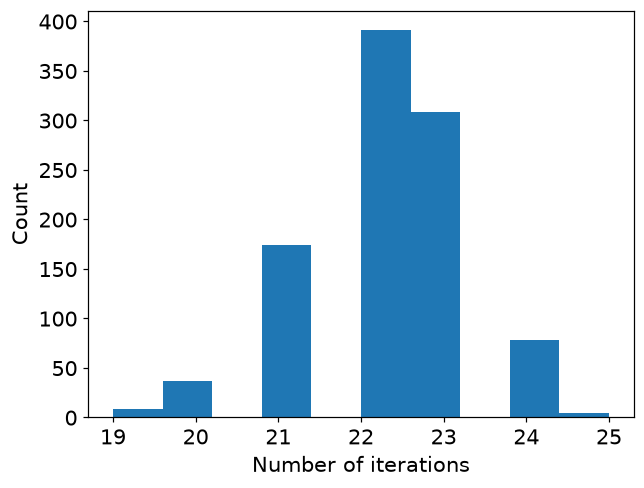

In [11]:
# The code below isn't part of the exercise, but I was curious to repeat the optimization
# 1000 times to see the distribution of numIters

nIters = np.zeros(1000)

for i in range(1000):
  # create two matrices
  A = np.random.randn(N,N)
  B = np.random.randn(N,N)

  numIters,s = 0,1
  while EuclideanDistance(s*A,s*B)>1:
    s *= .9
    numIters += 1
  nIters[i] = numIters

plt.hist(nIters)
plt.xlabel('Number of iterations')
plt.ylabel('Count');

## 연습문제 3 · trace로 노름 계산

- **목표**: $\|A\|_F^2=\operatorname{tr}(A^TA)$를 확인합니다.
- **풀이 순서**: $A^TA$ 대각합의 제곱근과 모든 원소 제곱합의 제곱근을 비교합니다.
- **결과 해석**: 차이는 0 근처입니다. 둘 다 각 열의 자기 내적을 모두 더한 값이기 때문입니다.

### 코드 05-11

- 원본: `original_py/LA4DS_ch05.py` 231–242행.

In [12]:
# Create a matrix
M = 50
A = np.random.randn(M,M)

# trace method
norm1 = np.sqrt(np.sum(np.diag(A.T@A)))

# Euclidean norm method
norm2 = np.sqrt(np.sum(A**2))

# if they're equal, their difference should be (very close to) zero
norm1-norm2

Out[12]: np.float64(0.0)


## 연습문제 4 · 대각 이동의 영향

- **목표**: $A+s\|A\|_FI$가 원본과 얼마나 달라지는지 측정합니다.
- **풀이 순서**: s를 바꾸면서 노름 변화율, 펼친 원소들의 상관, 원본과 거리를 계산합니다.
- **결과 해석**: 거리에는 정확히 $|s|\|A\|_F\sqrt N$ 관계가 있습니다. 노름은 대각 원소와의 교차항 때문에 모든 A에서 단조 증가하는 것은 아닙니다.

### 코드 05-12

- 원본: `original_py/LA4DS_ch05.py` 246–291행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

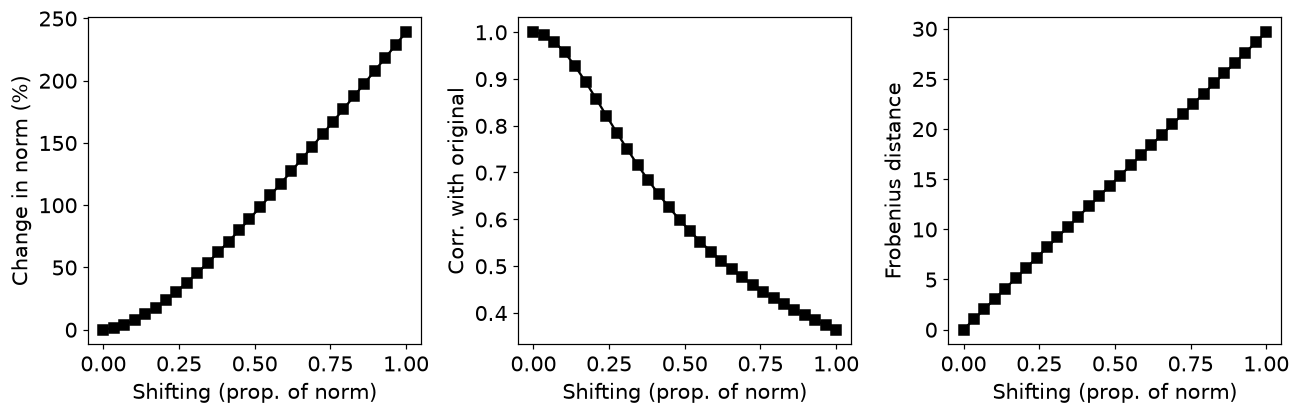

In [13]:
# size of the matrix
N = 10

shifting = np.linspace(0,1,30)

# original matrix
A = np.random.randn(N,N)
normA = np.linalg.norm(A,'fro')

# initialize results matrices
shiftingResults = np.zeros( (len(shifting),3) )
resultsNames = [ 'Change in norm (%)','Corr. with original','Frobenius distance' ]



for si in range(len(shifting)):

  # shift the matrix
  As = A + shifting[si]*normA*np.eye(N)

  # get the new norm and transform to %-change
  normShift = np.linalg.norm(As,'fro')
  shiftingResults[si,0] = 100 * (normShift-normA)/normA

  # compute correlation
  shiftingResults[si,1] = np.corrcoef(A.flatten(),As.flatten())[0,1]

  # Frobenius distance
  shiftingResults[si,2] = EuclideanDistance(A,As)




## plotting!
_,axs = plt.subplots(1,3,figsize=(12,4))

for i in range(3):

  # plot the results
  axs[i].plot(shifting,shiftingResults[:,i],'ks-')
  axs[i].set_xlabel('Shifting (prop. of norm)')
  axs[i].set_ylabel(resultsNames[i])

plt.tight_layout()
plt.savefig(ASSET / 'Figure_05_06.png',dpi=140)
plt.show()

## 연습문제 5 · 지정 랭크 행렬 만들기

- **목표**: 얇은 두 행렬의 곱으로 낮은 랭크를 구성합니다.
- **풀이 순서**: 5×3 난수 행렬과 3×8 난수 행렬을 곱하고 결과 shape와 rank를 출력합니다.
- **결과 해석**: shape는 (5,8), 일반적인 난수 입력에서는 rank 3입니다. 항상 랭크가 3 이하라는 것은 보장되지만 특수 입력에서는 더 작을 수 있습니다.

### 코드 05-13

- 원본: `original_py/LA4DS_ch05.py` 295–304행.

In [14]:
# Make a matrix with specified size and rank

M = 5
N = 8
r = 3

A = np.random.randn(M,r) @ np.random.randn(r,N)

print(A.shape)
print(np.linalg.matrix_rank(A))

(5, 8)
3


## 연습문제 6 · 합의 랭크는 다양하다

- **목표**: 랭크 1 행렬 둘의 합이 0·1·2랭크가 될 수 있음을 확인합니다.
- **풀이 순서**: 상쇄되는 대각행렬, 같은 열공간을 쓰는 행렬, 독립 방향을 쓰는 행렬을 차례로 더합니다.
- **결과 해석**: 각 경우 랭크가 달라집니다. 합의 랭크는 단순히 두 랭크의 합이라고 단정할 수 없습니다.

### 코드 05-14

- 원본: `original_py/LA4DS_ch05.py` 308–315행.

In [15]:
# summed matrix has rank-0

A = np.diag([ 1,0,0,0,0])
B = np.diag([-1,0,0,0,0])
C = A+B

# print out their ranks
np.linalg.matrix_rank(A),np.linalg.matrix_rank(B),np.linalg.matrix_rank(C)

Out[15]: (np.int64(1), np.int64(1), np.int64(0))


### 코드 05-15

- 원본: `original_py/LA4DS_ch05.py` 317–325행.

In [16]:
# summed matrix has rank-1

A = np.diag([1,0,0,0,0])
B = np.zeros(A.shape)
B[0,1] = 10
C = A+B

# print out their ranks
np.linalg.matrix_rank(A),np.linalg.matrix_rank(B),np.linalg.matrix_rank(C)

Out[16]: (np.int64(1), np.int64(1), np.int64(1))


### 코드 05-16

- 원본: `original_py/LA4DS_ch05.py` 327–334행.

In [17]:
# summed matrix has rank-2

A = np.diag([1,0,0,0,0])
B = np.diag([0,1,0,0,0])
C = A+B

# print out their ranks
np.linalg.matrix_rank(A),np.linalg.matrix_rank(B),np.linalg.matrix_rank(C)

Out[17]: (np.int64(1), np.int64(1), np.int64(2))


### 코드 05-17

- 원본: `original_py/LA4DS_ch05.py` 336–342행.

In [18]:
# random matrices have maximum possible rank!
A = np.random.randn(5,1) @ np.random.randn(1,5)
B = np.random.randn(5,1) @ np.random.randn(1,5)
C = A+B

# print out their ranks
np.linalg.matrix_rank(A),np.linalg.matrix_rank(B),np.linalg.matrix_rank(C)

Out[18]: (np.int64(1), np.int64(1), np.int64(2))


## 연습문제 7 · 합과 곱의 랭크 실험

- **목표**: 랭크 상한을 여러 조합의 열지도에서 관찰합니다.
- **풀이 순서**: 지정 랭크 난수 행렬 생성 함수를 만든 후 랭크 쌍별로 합과 곱의 랭크를 계산합니다.
- **결과 해석**: 합은 독립 방향을 더할 수 있지만 곱은 더 작은 랭크를 넘지 못합니다. 색 범위가 제한되므로 포화된 색만으로 정확한 숫자를 읽지 않습니다.

### 코드 05-18

- 원본: `original_py/LA4DS_ch05.py` 346–391행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

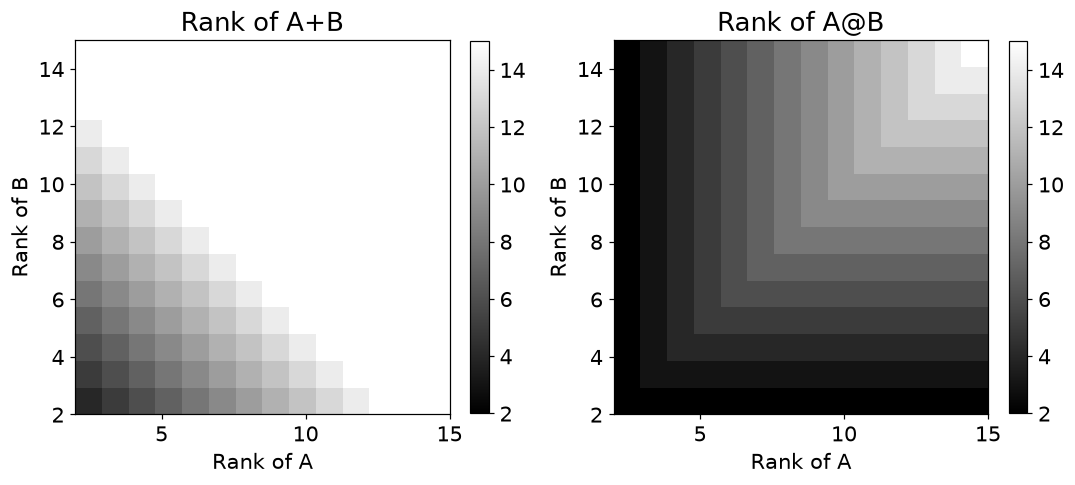

In [19]:
# The function
def makeAmatrix(M,r):
  return np.random.randn(M,r) @ np.random.randn(r,M)


# parameters
matSize = 20 # matrix size (square)
rs = range(2,16) # range of ranks

# initialize results matrix
Ranks = np.zeros((len(rs),len(rs),2))

# run the simulation
for i in range(len(rs)):
  for j in range(len(rs)):

    # create the matrices
    S = makeAmatrix(matSize,rs[i]) + makeAmatrix(matSize,rs[j])
    M = makeAmatrix(matSize,rs[i]) @ makeAmatrix(matSize,rs[j])
    
    # compute their ranks
    Ranks[i,j,0] = np.linalg.matrix_rank(S)
    Ranks[i,j,1] = np.linalg.matrix_rank(M)



## visualization
fig,axs = plt.subplots(1,2,figsize=(10,6))
s = '+@' # symbols for title

for i in range(2):

  # draw heatmat
  h = axs[i].imshow(Ranks[:,:,i],vmin=np.min(rs),vmax=np.max(rs),origin='lower',
                    extent=(rs[0],rs[-1],rs[0],rs[-1]),cmap='gray')
  
  # add colorbar and other niceties
  fig.colorbar(h,ax=axs[i],fraction=.045)
  axs[i].set_xlabel('Rank of A')
  axs[i].set_ylabel('Rank of B')
  axs[i].set_title(f'Rank of A{s[i]}B')


plt.savefig(ASSET / 'Figure_05_09.png',dpi=140)
plt.tight_layout()
plt.show()

## 연습문제 8 · 전치·Gram 행렬의 랭크

- **목표**: A, 전치, 두 Gram 행렬의 정보 방향 수를 비교합니다.
- **풀이 순서**: 15×8의 랭크 4 행렬을 만들고 A, At, AtA, AAt의 수치 랭크를 계산합니다.
- **결과 해석**: 이 예제에서는 모두 4입니다. 이론적 동일성과 수치 허용오차에 의한 판정 차이는 구분해야 합니다.

### 코드 05-19

- 원본: `original_py/LA4DS_ch05.py` 395–412행.

In [20]:
# matrix sizes and rank
M = 15
N = 8
r = 4

# compute the four matrices
A   = np.random.randn(M,r) @ np.random.randn(r,N)
At  = A.T
AtA = A.T@A
AAt = A@A.T

# print their ranks
print(
    np.linalg.matrix_rank(A),
    np.linalg.matrix_rank(At),
    np.linalg.matrix_rank(AtA),
    np.linalg.matrix_rank(AAt)
)

4 4 4 4


## 연습문제 9 · 열공간 소속 검사

- **목표**: 벡터 추가가 랭크를 늘리는지로 표현 가능성을 판단합니다.
- **풀이 순서**: 행 수가 같은지 검사한 후 `[A|v]`의 랭크를 A와 비교합니다.
- **결과 해석**: 같으면 v가 기존 열공간 안에 있습니다. 4×3 임의 행렬과 독립 난수 벡터는 보통 False입니다. `v=A@c`로 만들면 True를 확인할 수 있습니다.

### 코드 05-20

- 원본: `original_py/LA4DS_ch05.py` 416–436행.

In [21]:
# function to run algorithm
def is_V_inColA(A,v):

  # check sizes
  if A.shape[0]!=v.shape[0]:
    raise Exception('Size mismatch! A and v must have the same column dimensionality!.')

  # compute ranks
  rankA  = np.linalg.matrix_rank(A)
  rankAv = np.linalg.matrix_rank( np.hstack((A,v)) )

  # function outputs TRUE if v \in C(A)
  return rankA==rankAv


# create matrix and vector
A = np.random.randn(4,3)
v = np.random.randn(4,1)

# test!
is_V_inColA(A,v)

Out[21]: np.False_


## 연습문제 10 · 특이행렬의 행렬식 오차

- **목표**: 정확한 0이 컴퓨터에서도 항상 0인지 실험합니다.
- **풀이 순서**: 두 열을 같게 만든 행렬의 크기를 늘리며 행렬식 절댓값을 여러 번 측정하고 평균의 로그를 그립니다.
- **결과 해석**: 수학적으로는 모두 0입니다. 작은 비영 값은 반올림 오차입니다. 계산값이 정확한 0이면 log에서 -inf가 나올 수 있으며 그 점은 유한한 세로축에 표시되지 않습니다.

### 코드 05-21

- 원본: `original_py/LA4DS_ch05.py` 440–473행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

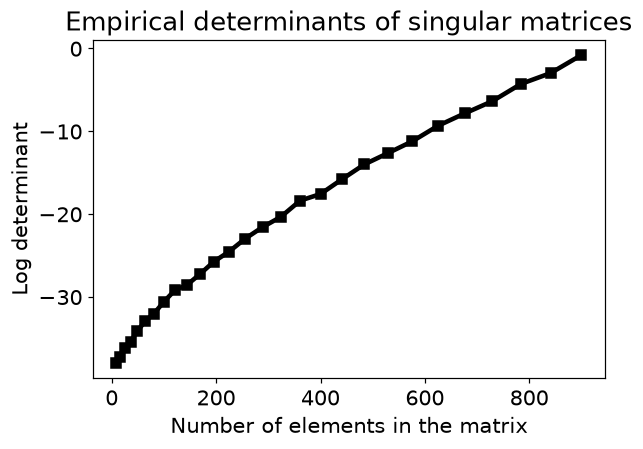

In [22]:
# matrix sizes
ns = np.arange(3,31)

# iteration
iters = 100

# initialize
dets = np.zeros((len(ns),iters))

# loop over matrix sizes
for ni in range(len(ns)):
  for i in range(iters):
      
    # step 1
    A = np.random.randn(ns[ni],ns[ni])
    
    # step 2
    A[:,0] = A[:,1]
    
    # step 3
    dets[ni,i]=np.abs(np.linalg.det(A))
        

# note: the number of elements in a square matrix is the columns squared


# plotting
plt.figure(figsize=(6,4))
plt.plot(ns**2,np.log(np.mean(dets,axis=1)),'ks-',linewidth=3)
plt.xlabel('Number of elements in the matrix')
plt.ylabel('Log determinant')
plt.title('Empirical determinants of singular matrices')
plt.savefig(ASSET / 'Figure_05_10.png',dpi=140)
plt.show()

## 핵심 결과 다시 확인하기

- 아래는 원본과 별도로 추가한 작은 검증 예제입니다.
- `assert`가 통과하면 해당 수학적 관계가 지정한 수치 허용오차 안에서 성립한 것입니다.
- 큰 예제의 숫자를 외우기보다 이 관계가 왜 성립하는지 설명해 보세요.

In [23]:
_A=np.array([[1.,2.],[3.,6.]]); _z=np.array([-2.,1.])
print('랭크:',np.linalg.matrix_rank(_A),'영공간 벡터의 출력:',_A@_z)
print('Frobenius 노름:',np.linalg.norm(_A,'fro'))
assert np.linalg.matrix_rank(_A)==1 and np.allclose(_A@_z,0)
assert np.allclose(np.linalg.norm(_A,'fro')**2,np.trace(_A.T@_A))


랭크: 1 영공간 벡터의 출력: [0. 0.]
Frobenius 노름: 7.0710678118654755
